In [59]:
LOWEST_PRICE = 0
HIGHEST_PRICE = 1
RESOLUTION = 0.1

In [136]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [63]:
prices = np.arange(LOWEST_PRICE, HIGHEST_PRICE+RESOLUTION, RESOLUTION)
prices

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [14]:
def cdf(x):
    out = lambda x: x
    assert out(LOWEST_PRICE) == 0
    assert out(HIGHEST_PRICE) == 1
    return out(x)

In [15]:
cdf(0.5)

0.5

In [110]:
def solve(cdf, T: int):
    value = defaultdict(lambda: 0)
    action = {}
    for t in range(T, 0, -1):
        for cash in np.arange(0, HIGHEST_PRICE*T, 0.1):
            for inv in range(0, T+1):
                if t == T:
                    value[(cash, inv, t)] = cash
                else:
                    max_value = -1
                    best_bid = -1
                    best_ask = -1
                    allowed_bids = [price for price in prices if price <= cash]
                    allowed_asks = [0] if inv == 0 else prices
                    # print(cash, inv, t, allowed_bids, allowed_asks)
                    for bid in allowed_bids:
                        for ask in [price for price in prices if price >= bid]:
                            v = cdf(bid) * value[(round(cash-bid, 1), inv+1, t+1)] + \
                                (cdf(ask) - cdf(bid)) * value[(round(cash, 1), inv, t+1)] + \
                                (1 - cdf(ask)) * value[(round(cash+ask, 1), inv-1, t+1)]
                            if v > max_value:
                                max_value = v
                                best_bid = bid
                                best_ask = ask
                    value[(cash, inv, t)] = max_value
                    action[(cash, inv, t)] = [best_bid, best_ask]

    return value, action

In [83]:
value, action = solve(cdf, 10)

In [84]:
value[(0, 1, 1)]

0.8678317449999999

In [85]:
action[(0, 1, 1)]

[0.0, 0.8]

In [172]:
fixed_i = 1
fixed_j = 0
value_slice = {k: value[(fixed_i, fixed_j, k)] for k in range(0, 11) if (fixed_i, fixed_j, k) in value}

In [173]:
value_slice

{1: 1.4022985212000005,
 2: 1.3319053260000004,
 3: 1.2659104200000004,
 4: 1.2047562000000003,
 5: 1.1482980000000003,
 6: 1.0950600000000001,
 7: 1.0482,
 8: 1.014,
 9: 1.0,
 10: 1.0}

In [174]:
ks, vs = zip(*value_slice.items())

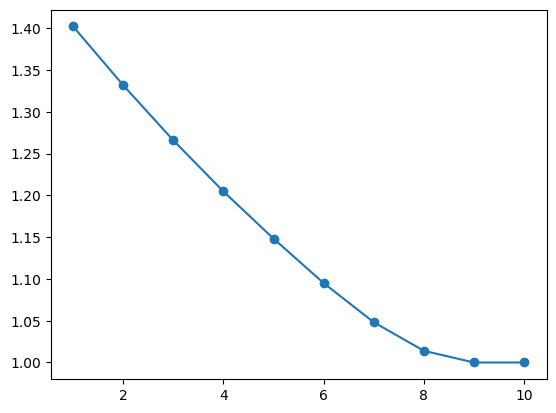

In [175]:
plt.plot(ks, vs, marker='o')

In [115]:
action_slice = {k: action[(fixed_i, fixed_j, k)] for k in range(0, 11) if (fixed_i, fixed_j, k) in action}

In [116]:
action_slice

{1: [0.0, 0.8],
 2: [0.0, 0.8],
 3: [0.0, 0.8],
 4: [0.0, 0.5],
 5: [0.0, 0.5],
 6: [0.0, 0.5],
 7: [0.0, 0.5],
 8: [0.0, 0.5],
 9: [0.0, 0.5]}

In [117]:
bids_slice = [(k, v[0]) for k, v in action_slice.items()]
asks_slice = [(k, v[1]) for k, v in action_slice.items()]

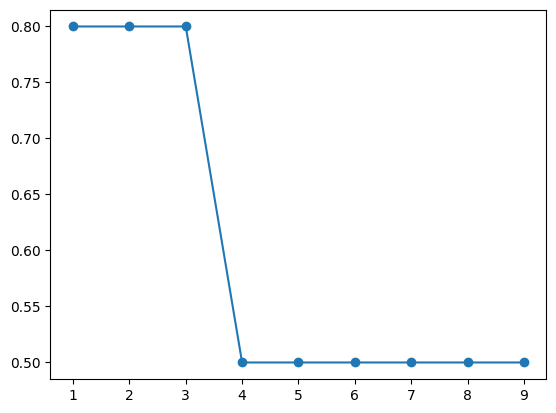

In [118]:
ks, vs = zip(*asks_slice)
plt.plot(ks, vs, marker='o')

In [140]:



# plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')
# plt.title('Histogram of Samples from Custom Distribution')
# plt.show()


In [141]:
samples

array([0.62389396, 0.27055104, 0.98719102, 0.71061327, 0.87525493,
       0.4723119 , 0.86281675, 0.38793171, 0.84573162, 0.82308521])

In [170]:
def simulate(value, action, T, start_cash=1, start_inv=0):
    x_values = np.linspace(LOWEST_PRICE, HIGHEST_PRICE, 1000)
    cdf_values = cdf(x_values)
    inverse_cdf = interp1d(cdf_values, x_values, kind='linear')
    uniform_samples = np.random.uniform(0, 1, size=9)
    samples = inverse_cdf(uniform_samples)

    cash = [start_cash]
    inv = [start_inv]
    bids = []
    asks = []
    times = []
    for t, p in enumerate(samples):
        t = t + 1
        times.append(t)
        act = action[(round(cash[-1], 1), inv[-1], t)]
        bid = act[0]
        ask = act[1]
        bids.append(bid)
        asks.append(ask)
        if p <= bid:
            cash.append(cash[-1]-bid)
            inv.append(inv[-1]+1)
        elif p >= ask:
            cash.append(cash[-1]+ask)
            inv.append(inv[-1]-1)
        else:
            cash.append(cash[-1])
            inv.append(inv[-1])

    # Sample data
    x = [0]+times
    y1 = cash
    y2 = inv
    y3 = bids+[0]
    y4 = asks+[0]
    
    # Create a figure and a grid of subplots
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    
    # Plot the data
    axs[0, 0].plot(x, y1, 'r-')  # Red line for y1 vs x
    axs[0, 1].plot(x, y2, 'g-')  # Green line for y2 vs x
    axs[1, 0].plot(x, y3, 'b-')  # Blue line for y3 vs x
    axs[1, 1].plot(x, y4, 'm-')
    
    # Set labels for each subplot
    axs[0, 0].set_title('cash')
    axs[0, 1].set_title('inv')
    axs[1, 0].set_title('bid')
    axs[1, 1].set_title('ask')
    
    # Adjust the layout and show the plot
    plt.tight_layout()
    plt.show()

        
    

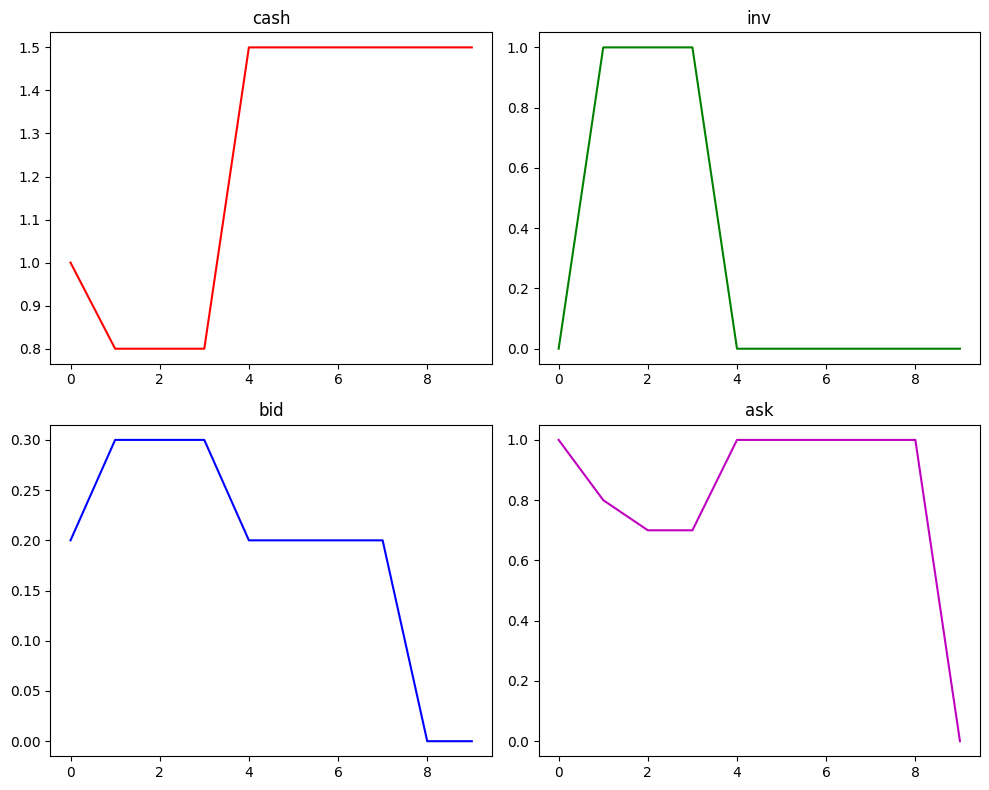

In [171]:
simulate(value, action, 10)